<a href="https://colab.research.google.com/github/Lindart0312/machine-learning-practice/blob/main/03_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 전처리

## 넘파이로 데이터 준비하기

In [ ]:
# 도미와 빙어의 길이, 무게
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [11]:
import numpy as np

In [12]:
# 배열을 위아래로 합치기
np.column_stack(([1,2,3], [4,5,6]))

array([[1, 4],
       [2, 5],
       [3, 6]])

In [16]:
fish_data = np.column_stack((fish_length, fish_weight))

NameError: name 'fish_length' is not defined

In [17]:
# 0 ~ 4 인덱스의 배열 원소 5개 출력
print(fish_data[:5])

NameError: name 'fish_data' is not defined

In [ ]:
print(np.ones(5)) # 값이 1인 5개가 들어가있는 배열

[1. 1. 1. 1. 1.]


In [ ]:
# 배열 옆으로 이어 붙이기
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [ ]:
print(fish_target) # 1은 도미, 0은 빙어

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


## 사이킷런으로 훈련 세트와 테스트 세트 나누기

훈련 데이터 나누는거
- x데이터(length)와 y데이터(weight)를 구분해서 나누어야 함

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, random_state=42) # 차례대로 x데이터, y데이터가 들어감, 시드값을 고정시키면 항상 동일한 출력을 얻을 수 있음

NameError: name 'train_test_split' is not defined

In [ ]:
# 2차원 배열
print(train_input.shape, test_input.shape)

NameError: name 'train_input' is not defined

In [ ]:
# 1차원 배열
print(train_target.shape, test_target.shape)

(36,) (13,)


In [ ]:
# 샘플링 편향
print(test_target) # 도미의 편향이 확인됨

[1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, stratify=fish_target, random_state=42)

In [ ]:
print(test_target)

[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


## 수상한 도미 한마리

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier() # k최근접 이웃을 kn으로 둠
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [ ]:
print(kn.predict([[25, 150]])) # 수상한 도미 결과는 빙어(0)로 분류

[0.]


In [ ]:
import matplotlib.pyplot as plt

In [19]:
plt.scatter(train_input[:,0], train_input[:,1]) # 순서대로 (x데이터, y데이터)를 찍은거임
plt.scatter(25, 150, marker='^') # 세모 모양으로 찍어라 새로 들어온 친구를
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

NameError: name 'plt' is not defined

In [10]:
distances, indexes = kn.kneighbors([[25, 150]]) # k-최근접 이웃으로 찍어보자

NameError: name 'kn' is not defined

In [18]:
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

NameError: name 'plt' is not defined

In [ ]:
print(train_input[indexes])

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 14.3  19.7]
  [ 13.   12.2]
  [ 12.2  12.2]]]


In [ ]:
print(train_target[indexes])

[[1. 0. 0. 0. 0.]]


In [ ]:
print(distances)

[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]]


## 기준을 맞춰라

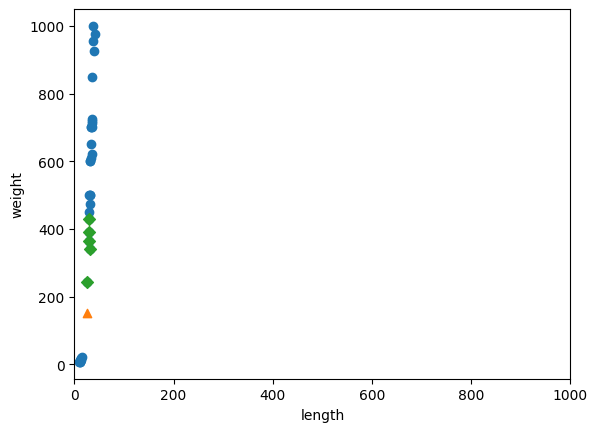

In [ ]:
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlim((0, 1000)) #x limit 값 1000으로 변경 단위 통일을 위해
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
# 평균, 표준편차 구하기 # 트레인 데이터셋으로 평균과 표준편차를 구해야함
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)

In [ ]:
print(mean, std)

[ 27.29722222 454.09722222] [  9.98244253 323.29893931]


In [ ]:
# 표준화
train_scaled = (train_input - mean) / std

## 전처리 데이터로 모델 훈련하기

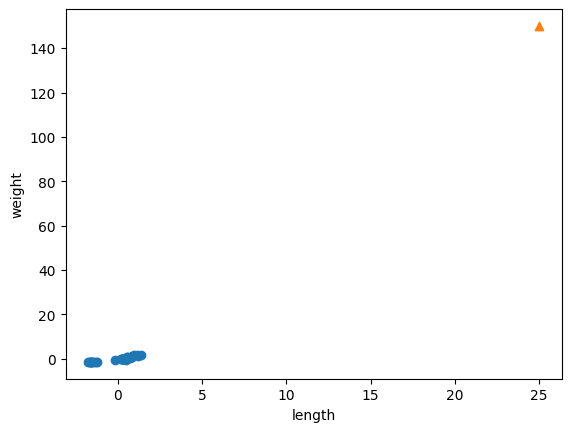

In [ ]:
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
new = ([25, 150] - mean) / std

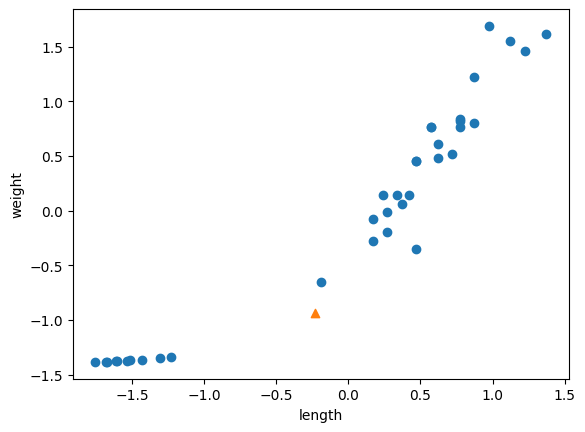

In [ ]:
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
kn.fit(train_scaled, train_target) # target은 0과1로 결과를 도출하니까 스케일링 필요X

KNeighborsClassifier()

In [ ]:
test_scaled = (test_input - mean) / std

In [ ]:
kn.score(test_scaled, test_target)

1.0

In [ ]:
print(kn.predict([new]))

[1.]


In [ ]:
distances, indexes = kn.kneighbors([new])

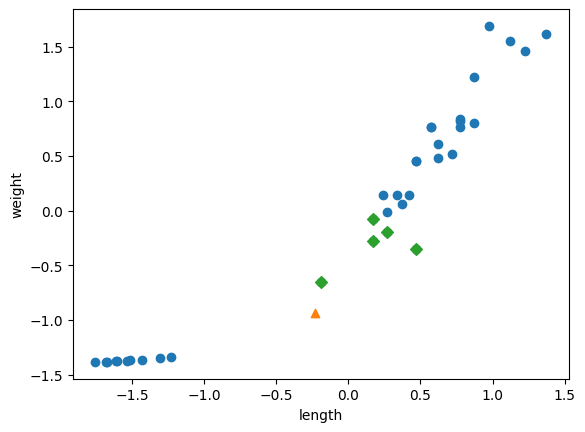

In [ ]:
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^')
plt.scatter(train_scaled[indexes,0], train_scaled[indexes,1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()